# Латентная стадия SEIR
Дополнительное задание 7: после заражения S→E; E ещё не заразны.
Время E→I экспоненциальное со средним 1/σ. Выздоровление отсчитывается
с перехода в I, а не с заражения. Сравнение с SIR на одинаковых seed.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
rows=NamedTuple[]
fig=plot(;xlabel="Time",ylabel="I",title="Latent period: seed=6001",size=(1000,550))
for sigma in [Inf,.25,.5,1.0], rep in 1:10
    model,result=simulate(family="seir",sigma=sigma,seed=6000+rep)
    push!(rows,result)
    if rep==1
        plot!(fig,model.ta,model.Ia;label=isinf(sigma) ? "SIR" : "SEIR sigma=$(sigma)",lw=2)
        if sigma==.5
            states=plot_states(out(model);title="SEIR sigma=0.5",exposed=true)
            savefig(states,figure_path("13-plot"))
        end
    end
end
runs=save_table("seir-runs",DataFrame(rows));

Row,sigma,replicates,peak_mean,peak_sd,peak_time_mean,R_fraction_mean,infected_mean,I_T_mean,extinction_fraction
,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Inf,10,167.2,24.9479,18.8708,0.7505,770.5,20.0,0.0
2,0.25,10,84.0,15.2242,35.5924,0.3647,512.6,71.1,0.0
3,0.5,10,115.9,14.3562,33.521,0.537,660.7,87.9,0.0
4,1.0,10,132.5,16.6617,25.6383,0.6847,742.8,50.7,0.0


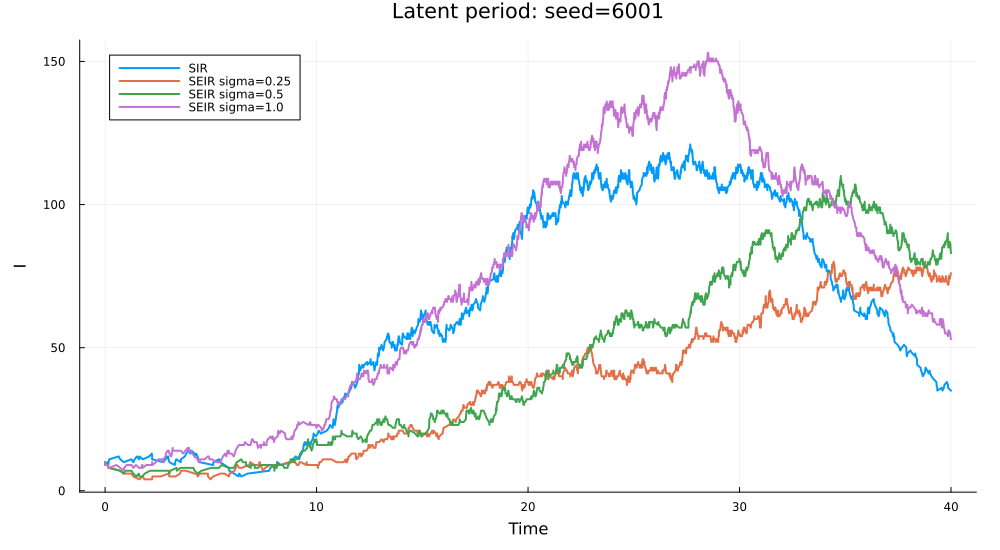

In [3]:
summary=save_table("seir-summary",summarize(runs,[:sigma]))
display(summary)
savefig(fig,figure_path("12-plot"))
display(fig)

## Все четыре состояния
При T=40 часть особей может оставаться в E или I, поэтому различие R(T)
не следует интерпретировать как доказательство разного финального размера.

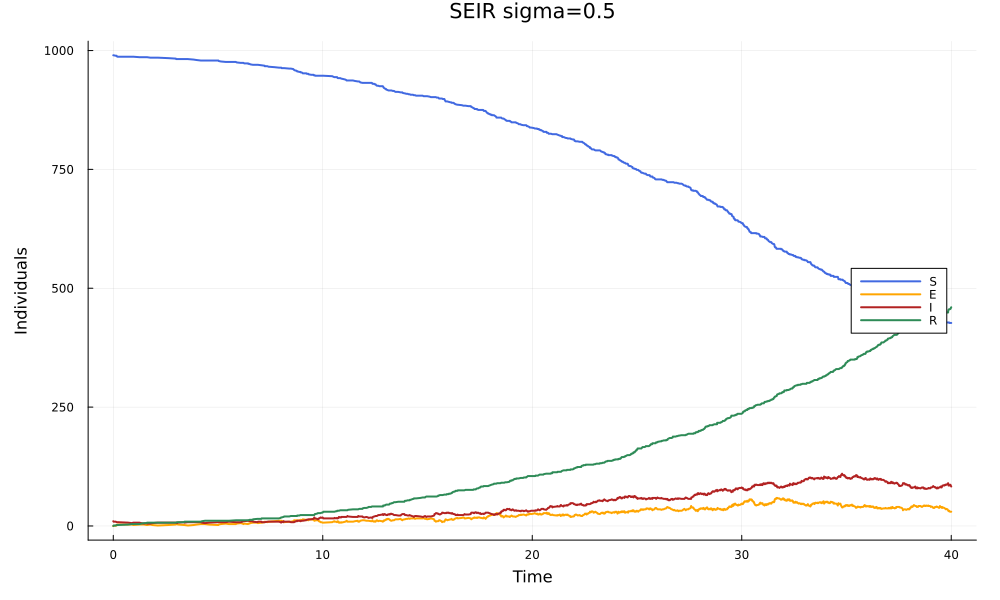

In [4]:
selected=filter(r->r.sigma==.5 && r.seed==6001,runs)
trajectory=CSV.read(projectdir(selected.csv[1]),DataFrame)
@assert all(trajectory.S+trajectory.E+trajectory.I+trajectory.R .== 1000)
display(plot_states(trajectory;title="SEIR sigma=0.5",exposed=true))